In [1]:
!unzip train.zip
!unzip val.zip
!unzip test.zip

unzip:  cannot find or open train.zip, train.zip.zip or train.zip.ZIP.
unzip:  cannot find or open val.zip, val.zip.zip or val.zip.ZIP.
unzip:  cannot find or open test.zip, test.zip.zip or test.zip.ZIP.


In [ ]:
!unzip "/content/drive/MyDrive/train.zip"

Streaming output truncated to the last 5000 lines.
  inflating: train/pre-event/scene_08_000365_building_damage.tif  
  inflating: train/pre-event/scene_06_000767_building_damage.tif  
  inflating: train/pre-event/scene_08_000102_building_damage.tif  
  inflating: train/pre-event/scene_08_000684_building_damage.tif  
  inflating: train/pre-event/scene_03_000082_building_damage.tif  
  inflating: train/pre-event/scene_08_000873_building_damage.tif  
  inflating: train/pre-event/scene_06_000718_building_damage.tif  
  inflating: train/pre-event/scene_08_000141_building_damage.tif  
  inflating: train/pre-event/scene_07_000450_building_damage.tif  
  inflating: train/pre-event/scene_06_000325_building_damage.tif  
  inflating: train/pre-event/scene_07_000069_building_damage.tif  
  inflating: train/pre-event/scene_07_000499_building_damage.tif  
  inflating: train/pre-event/scene_07_000101_building_damage.tif  
  inflating: train/pre-event/scene_08_000193_building_damage.tif  
  inflating

In [ ]:
import os

print("TRAIN:")
print(os.listdir('train'))

print("\nVAL:")
print(os.listdir('val'))

print("\nTEST:")
print(os.listdir('test'))

TRAIN:
['post-event', 'target', 'pre-event']

VAL:
['post-event', 'target', 'pre-event']

TEST:
['post-event', 'target', 'pre-event']


In [ ]:
train_pre = os.listdir('train/pre-event')
train_post = os.listdir('train/post-event')
train_mask = os.listdir('train/target')

print("Number of pre-event images:", len(train_pre))
print("Number of post-event images:", len(train_post))
print("Number of masks:", len(train_mask))

print("\nSample file:")
print(train_pre[0])

Number of pre-event images: 2781
Number of post-event images: 2781
Number of masks: 2781

Sample file:
scene_08_000546_building_damage.tif


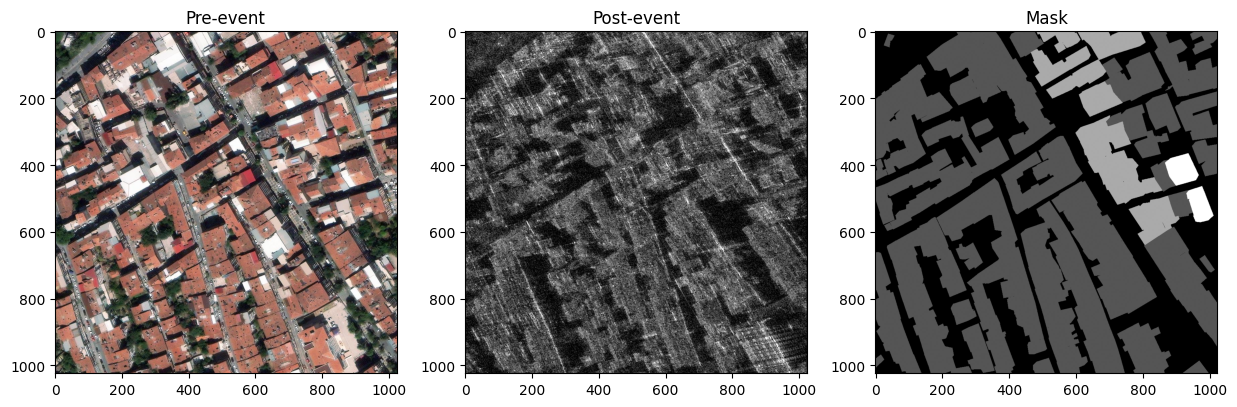

Pre-event shape: (1024, 1024, 3)
Post-event shape: (1024, 1024, 3)
Mask shape: (1024, 1024)
Mask unique values: [0 1 2 3]


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

sample_name = train_pre[0]

pre_path = os.path.join('train/pre-event', sample_name)
post_path = os.path.join('train/post-event', sample_name)
mask_path = os.path.join('train/target', sample_name)

# Read images
pre_img = cv2.imread(pre_path)
post_img = cv2.imread(post_path)
mask = cv2.imread(mask_path, 0)

# Convert BGR -> RGB
pre_img = cv2.cvtColor(pre_img, cv2.COLOR_BGR2RGB)
post_img = cv2.cvtColor(post_img, cv2.COLOR_BGR2RGB)

# Plot
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(pre_img)
plt.title("Pre-event")

plt.subplot(1,3,2)
plt.imshow(post_img)
plt.title("Post-event")

plt.subplot(1,3,3)
plt.imshow(mask, cmap='gray')
plt.title("Mask")

plt.show()

# Print details
print("Pre-event shape:", pre_img.shape)
print("Post-event shape:", post_img.shape)
print("Mask shape:", mask.shape)

print("Mask unique values:", np.unique(mask))

In [ ]:
def remap_mask(mask):
    """
    Original:
    0 -> 0
    1 -> 0
    2 -> 1
    3 -> 1
    """

    remapped = np.zeros_like(mask)

    remapped[(mask == 2) | (mask == 3)] = 1

    return remapped

Original mask values: [0 1 2 3]
Remapped mask values: [0 1]


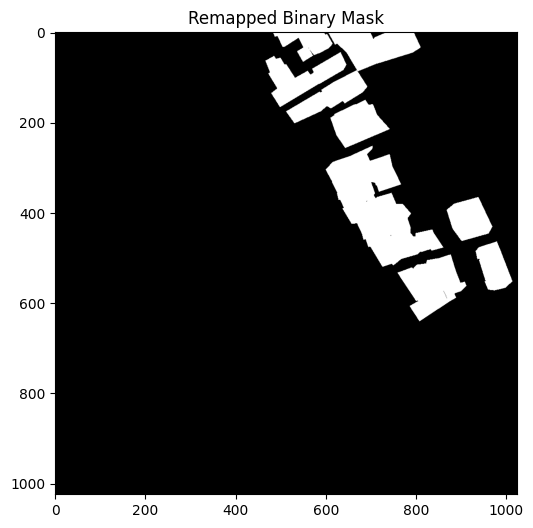

In [ ]:
new_mask = remap_mask(mask)

print("Original mask values:", np.unique(mask))
print("Remapped mask values:", np.unique(new_mask))

plt.figure(figsize=(6,6))
plt.imshow(new_mask, cmap='gray')
plt.title("Remapped Binary Mask")
plt.show()

In [ ]:
import albumentations as A

train_transform = A.Compose([
    A.Resize(256, 256),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.RandomBrightnessContrast(p=0.3),

    A.Normalize()
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize()
])

In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.4 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

import albumentations as A
import segmentation_models_pytorch as smp

In [ ]:
class ChangeDetectionDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.pre_dir = os.path.join(root_dir, 'pre-event')
        self.post_dir = os.path.join(root_dir, 'post-event')
        self.mask_dir = os.path.join(root_dir, 'target')

        self.image_names = sorted(os.listdir(self.pre_dir))

        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):

        image_name = self.image_names[idx]

        pre_path = os.path.join(self.pre_dir, image_name)
        post_path = os.path.join(self.post_dir, image_name)
        mask_path = os.path.join(self.mask_dir, image_name)

        # Read images
        pre_img = cv2.imread(pre_path)
        post_img = cv2.imread(post_path)

        pre_img = cv2.cvtColor(pre_img, cv2.COLOR_BGR2RGB)
        post_img = cv2.cvtColor(post_img, cv2.COLOR_BGR2RGB)

        # Read mask
        mask = cv2.imread(mask_path, 0)

        # Remap labels
        mask = remap_mask(mask)

        # Concatenate pre and post images
        image = np.concatenate([pre_img, post_img], axis=-1)

        # Apply transforms
        if self.transform:

            augmented = self.transform(
                image=image,
                mask=mask.astype(np.uint8)
            )

            image = augmented['image']
            mask = augmented['mask']

            # Ensure binary mask
            mask = (mask > 0).astype(np.float32)

        # Convert to tensor
        image = torch.tensor(image).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

In [ ]:
train_dataset = ChangeDetectionDataset(
    root_dir='train',
    transform=train_transform
)

val_dataset = ChangeDetectionDataset(
    root_dir='val',
    transform=val_transform
)

test_dataset = ChangeDetectionDataset(
    root_dir='test',
    transform=val_transform
)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 2781
Val samples: 334
Test samples: 77


In [ ]:
image, mask = train_dataset[0]

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

print("Mask unique values:", torch.unique(mask))

Image shape: torch.Size([6, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Mask unique values: tensor([0.])


In [ ]:
for i in range(100):

    _, mask = train_dataset[i]

    unique_vals = torch.unique(mask)

    if len(unique_vals) > 1:
        print(f"Sample {i} contains CHANGE pixels:", unique_vals)

Sample 20 contains CHANGE pixels: tensor([0., 1.])
Sample 21 contains CHANGE pixels: tensor([0., 1.])
Sample 24 contains CHANGE pixels: tensor([0., 1.])
Sample 25 contains CHANGE pixels: tensor([0., 1.])
Sample 27 contains CHANGE pixels: tensor([0., 1.])
Sample 28 contains CHANGE pixels: tensor([0., 1.])
Sample 29 contains CHANGE pixels: tensor([0., 1.])
Sample 30 contains CHANGE pixels: tensor([0., 1.])
Sample 31 contains CHANGE pixels: tensor([0., 1.])
Sample 32 contains CHANGE pixels: tensor([0., 1.])
Sample 38 contains CHANGE pixels: tensor([0., 1.])
Sample 40 contains CHANGE pixels: tensor([0., 1.])
Sample 41 contains CHANGE pixels: tensor([0., 1.])
Sample 42 contains CHANGE pixels: tensor([0., 1.])
Sample 43 contains CHANGE pixels: tensor([0., 1.])
Sample 46 contains CHANGE pixels: tensor([0., 1.])
Sample 49 contains CHANGE pixels: tensor([0., 1.])
Sample 50 contains CHANGE pixels: tensor([0., 1.])
Sample 51 contains CHANGE pixels: tensor([0., 1.])
Sample 52 contains CHANGE pixel

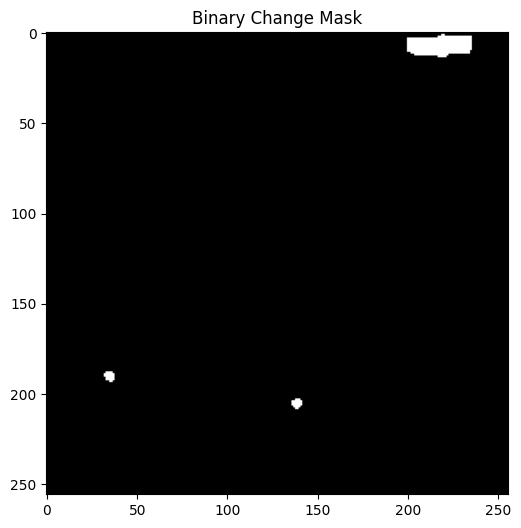

tensor([0., 1.])


In [ ]:
image, mask = train_dataset[27]

plt.figure(figsize=(6,6))
plt.imshow(mask.squeeze(), cmap='gray')
plt.title("Binary Change Mask")
plt.show()

print(torch.unique(mask))

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

In [ ]:
model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights=None,
    in_channels=6,
    classes=1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cuda


In [ ]:
bce_loss = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([8.0]).to(device)
)

dice_loss = smp.losses.DiceLoss(
    mode='binary'
)

def combined_loss(pred, target):

    bce = bce_loss(pred, target)

    dice = dice_loss(pred, target)

    return bce + dice

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
def iou_score(preds, masks, threshold=0.5):

    preds = torch.sigmoid(preds)

    preds = (preds > threshold).float()

    intersection = (preds * masks).sum()

    union = preds.sum() + masks.sum() - intersection

    iou = (intersection + 1e-6) / (union + 1e-6)

    return iou.item()

In [ ]:
num_epochs = 5

best_iou = 0

for epoch in range(num_epochs):

    # TRAINING
    model.train()

    train_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(outputs, masks)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # VALIDATION
    model.eval()

    val_iou = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            val_iou += iou_score(outputs, masks)

    avg_val_iou = val_iou / len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Validation IoU: {avg_val_iou:.4f}")

    # Save best model
    if avg_val_iou > best_iou:

        best_iou = avg_val_iou

        torch.save(model.state_dict(), "best_model.pth")

        print("Best model saved!")

Epoch [1/5]
Train Loss: 0.9975
Validation IoU: 0.0737
Best model saved!
Epoch [2/5]
Train Loss: 0.9706
Validation IoU: 0.0716
Epoch [3/5]
Train Loss: 0.9648
Validation IoU: 0.1061
Best model saved!
Epoch [4/5]
Train Loss: 0.9545
Validation IoU: 0.1090
Best model saved!
Epoch [5/5]
Train Loss: 0.9193
Validation IoU: 0.1427
Best model saved!


In [ ]:
model.load_state_dict(torch.load("best_model.pth"))

model.eval()

print("Best model loaded!")

Best model loaded!


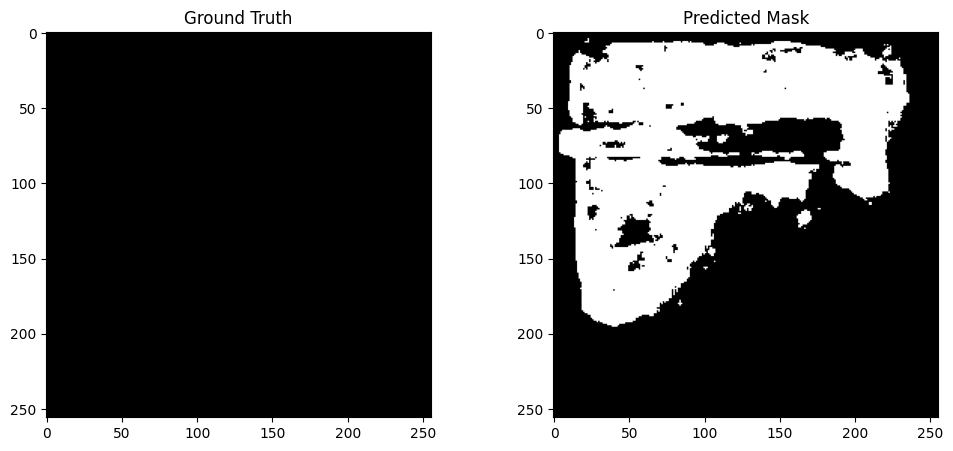

In [ ]:
import random

idx = random.randint(0, len(test_dataset)-1)

image, true_mask = test_dataset[idx]

input_tensor = image.unsqueeze(0).to(device)

with torch.no_grad():

    pred_mask = model(input_tensor)

    pred_mask = torch.sigmoid(pred_mask)

    pred_mask = (pred_mask > 0.5).float()

pred_mask = pred_mask.squeeze().cpu().numpy()

true_mask = true_mask.squeeze().numpy()

# Visualize
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(true_mask, cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,2,2)
plt.imshow(pred_mask, cmap='gray')
plt.title("Predicted Mask")

plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

all_preds = []
all_targets = []

model.eval()

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)

        outputs = model(images)

        outputs = torch.sigmoid(outputs)

        outputs = (outputs > 0.5).float()

        all_preds.extend(outputs.cpu().numpy().flatten())

        all_targets.extend(masks.numpy().flatten())

precision = precision_score(
    all_targets,
    all_preds,
    zero_division=0
)

recall = recall_score(
    all_targets,
    all_preds,
    zero_division=0
)

f1 = f1_score(
    all_targets,
    all_preds,
    zero_division=0
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.017763598408759698
Recall: 0.41407623094882084
F1 Score: 0.03406579651594413
